In [1]:
import pandas as pd
df = pd.read_csv("../datasets/Andalus_4Classes_Ghazal_Madh_Hijaa_Rithaa.csv")
list_of_requierd = ["غزل","مدح","رثاء"]

In [ ]:
# STEP 1: Install
# pip install tashaphyne

from tashaphyne.stemming import ArabicLightStemmer

class ArabicPoetryLightStemmer:
    """Light stemmer optimized for preserving poetic vocabulary"""
    
    def __init__(self):
        self.stemmer = ArabicLightStemmer()
    
    def light_stem(self, word):
        """
        Removes prefixes/suffixes but preserves the core poetic word.
        """
        self.stemmer.light_stem(word)
        return {
            'original': word,
            'stem': self.stemmer.get_stem(),
            'prefix': self.stemmer.get_prefix(),
            'suffix': self.stemmer.get_suffix()
        }
    
    def stem_poem(self, poem_text):
        """Stem an entire poem line-by-line"""
        words = poem_text.split()
        stemmed_words = []
        
        for word in words:
            self.stemmer.light_stem(word)
            stemmed_words.append(self.stemmer.get_stem())
        
        return ' '.join(stemmed_words)
    
    def batch_stem_poems(self, poems_list):
        """Process multiple poems"""
        return [self.stem_poem(poem) for poem in poems_list]

stemmer = ArabicPoetryLightStemmer()


In [ ]:
import re
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

poem_with_type = pd.DataFrame()
andalus = df
poems_without_diact = []
types = []
meters = []
for x in range(len(andalus["poem_text"])):
    
    one_bait = andalus["poem_text"].iloc[x]
    cleaned_text = str(one_bait).replace('\n', ' ')
    
    text = re.sub(r'[\u064B-\u065F]', '', str(cleaned_text))
    tokens = word_tokenize(cleaned_text.lower())
    stop_words = set(stopwords.words('arabic'))
    filtered_tokens = [word for word in tokens if word not in stop_words]
    
    
    tokens_without_diact = word_tokenize(text.lower())
    
    filtered_tokens_without_diact = [word for word in tokens_without_diact if word not in stop_words]
    filtered_tokens_without_diact = [stemmer.light_stem(word)["stem"] for word in filtered_tokens_without_diact]
    
    filtered_tokens = ' '.join(filtered_tokens)
    filtered_tokens_without_diact = ' '.join(filtered_tokens_without_diact)
    if len(filtered_tokens) < 700:
        
        poems_without_diact.append(filtered_tokens_without_diact)
        types.append(andalus["final_label"][x])
        
poem_with_type["poem"] = poems_without_diact
 
poem_with_type["type"] = types


In [4]:
poem_with_type["type"].value_counts()

type
غزل     815
مدح     473
رثاء    449
هجاء    217
Name: count, dtype: int64

In [5]:
df_sampled = poem_with_type.groupby('type').head(450)

In [6]:
# to keep only four themes
dff_sampled = df_sampled[df_sampled["type"].isin(list_of_requierd)]

In [7]:
dff_sampled

,poem,type
0,ترب مرحوم حاء قد ثوى نار رجيم بك ظى حل قعر تست...,رثاء
1,قد زار هوى موعد عاين در تم تلاقي عاتب عتب حلو ...,مدح
3,طود منيع أيهم بطل كم معلم ليال حاج عدت منال لي...,مدح
4,ساجل دموع ياغمام طارح شجو ياحمام قد في حول ناد...,رثاء
5,ربم ستضح حباب نفض ثوب مدام مر قاصر خطا تهادى م...,غزل
...,...,...
1916,زعفران ثوب محز روق طعم شتم بسا مصفر نات حسن حس...,رثاء
1918,خضر قي لون غض روق حسن منظر عيون ذك عرف مشكور أ...,رثاء
1922,شقيق إخاء يا قسيم صفاء ذو فه جوهر أدباء فضل جي...,رثاء
1940,قدم بهار بنفسج شرب على رياض غضه معشوق عاشق ذا ...,رثاء


In [8]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import KMeans

vectorizer = TfidfVectorizer(ngram_range=(1,10))
X = vectorizer.fit_transform(dff_sampled["poem"])  # Sparse, high-dimensional

In [9]:
dff_sampled["type"].value_counts()

type
مدح     450
غزل     450
رثاء    449
Name: count, dtype: int64

In [10]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, dff_sampled["type"], test_size=0.1, random_state=42)

In [ ]:
from sklearn.preprocessing import MaxAbsScaler
from sklearn.naive_bayes import MultinomialNB
from sklearn.pipeline import Pipeline

clf = Pipeline([
    ('scaler', MaxAbsScaler()),
    ('clf', MultinomialNB()),
])

clf.fit(X_train, y_train)

Pipeline(steps=[('scaler', MaxAbsScaler()), ('clf', MultinomialNB())])

In [12]:
accuracy = clf.score(X_train, y_train)
print(f"Train Accuracy: {accuracy * 100:.2f}%")
accuracy = clf.score(X_test, y_test)
print(f"Test Accuracy: {accuracy * 100:.2f}%")


Train Accuracy: 98.19%
Test Accuracy: 55.56%


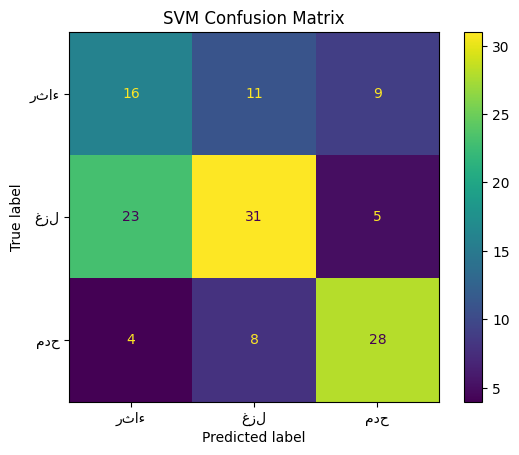

In [13]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

y_pred = clf.predict(X_test)

ConfusionMatrixDisplay.from_predictions(y_test, y_pred)
plt.title('SVM Confusion Matrix')
plt.show()